In [4]:
import pandas as pd
import tiktoken
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
import numpy as np
from scipy import stats
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_val_score,
    RandomizedSearchCV,
    GridSearchCV,
)
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet,
    LogisticRegression,
)
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
    VotingClassifier,
)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBClassifier
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

# from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score,
)
from sklearn.impute import SimpleImputer
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks

In [3]:
dft = pd.read_csv("D:\\database\\csv files\\customer_churn-training.csv")
# dft.drop(columns=["customerID"], inplace=True)
tezt_df = pd.read_csv(
    "D:\\database\\csv files\\customer_churn_dataset-testing-master.csv"
)
test = tezt_df.copy()
df = dft.copy()

In [ ]:
uni = {}

for i in df:
    uni[i] = df[i].unique()

uni

In [ ]:
# # Numerical features
# numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]

# # Categorical features to be one-hot encoded
# categorical_features = [
#     "MultipleLines",
#     "InternetService",
#     "OnlineSecurity",
#     "OnlineBackup",
#     "DeviceProtection",
#     "TechSupport",
#     "StreamingTV",
#     "StreamingMovies",
#     "PaymentMethod",
#     "Contract",
# ]

# # Binary / already numeric (used as-is)
# binary_features = [
#     "gender",
#     "SeniorCitizen",
#     "Partner",
#     "Dependents",
#     "PhoneService",
#     "PaperlessBilling",
#     "Churn",
# ]

In [3]:
# df[numeric_features] = df[numeric_features].apply(
#     lambda col: pd.to_numeric(col, errors="coerce")
# )
import numpy as np

# numeric_features = df.select_dtypes(include=[np.number]).columns
categorical_features = dft.select_dtypes(include=["object"]).columns
numeric_features = [
    "CustomerID",
    "Age",
    "Tenure",
    "Usage Frequency",
    "Support Calls",
    "Payment Delay",
    "Total Spend",
    "Last Interaction",
]
numeric_features_imputing = ["Churn"]

In [18]:
categorical_features

Index(['Gender', 'Subscription Type', 'Contract Length'], dtype='object')

In [211]:
df

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.00,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.00,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.00,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.00,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.00,20.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
440828,449995.0,42.0,Male,54.0,15.0,1.0,3.0,Premium,Annual,716.38,8.0,0.0
440829,449996.0,25.0,Female,8.0,13.0,1.0,20.0,Premium,Annual,745.38,2.0,0.0
440830,449997.0,26.0,Male,35.0,27.0,1.0,5.0,Standard,Quarterly,977.31,9.0,0.0
440831,449998.0,28.0,Male,55.0,14.0,2.0,0.0,Standard,Quarterly,602.55,2.0,0.0


In [16]:
df[numeric_features].corr()["Churn"].sort_values(ascending=False)

Churn               1.000000
Support Calls       0.574267
Payment Delay       0.312129
Age                 0.218394
Last Interaction    0.149616
Usage Frequency    -0.046101
Tenure             -0.051919
Total Spend        -0.429355
CustomerID         -0.839365
Name: Churn, dtype: float64

<Axes: xlabel='Churn', ylabel='count'>

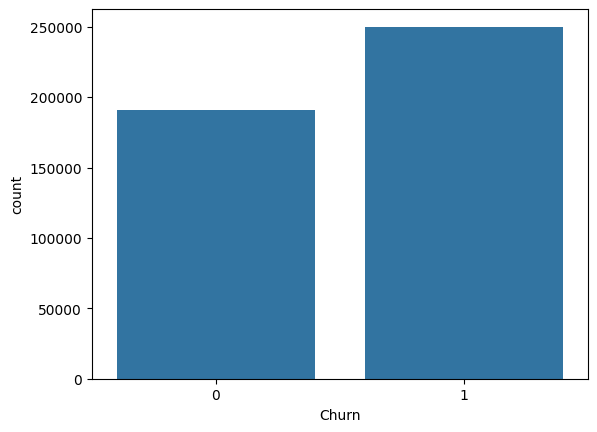

In [165]:
sns.countplot(x=y)

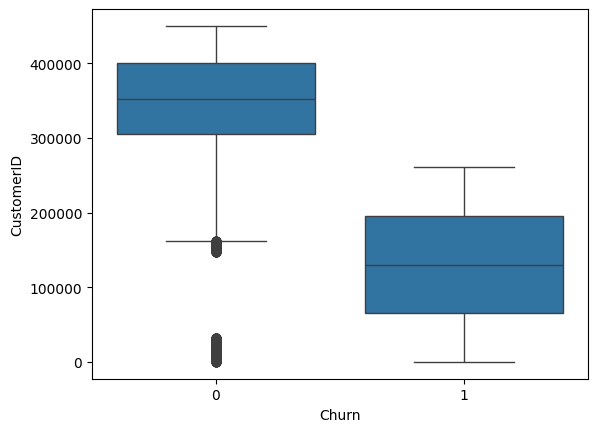

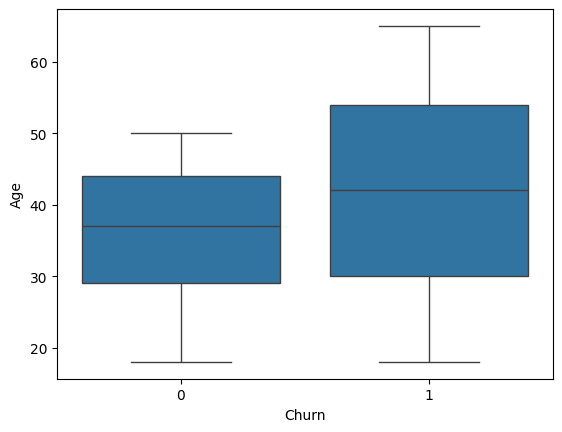

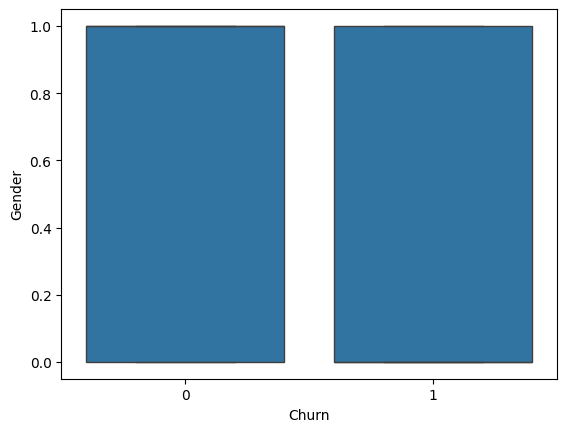

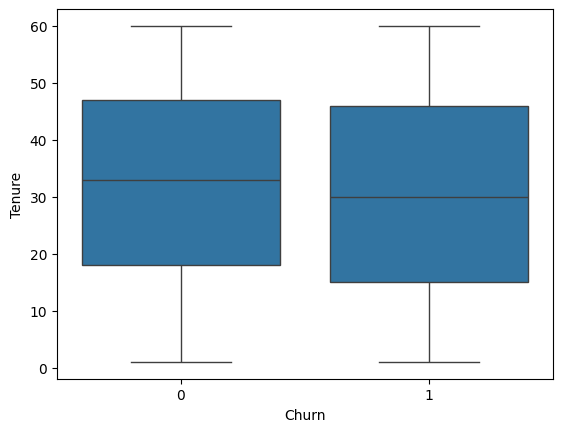

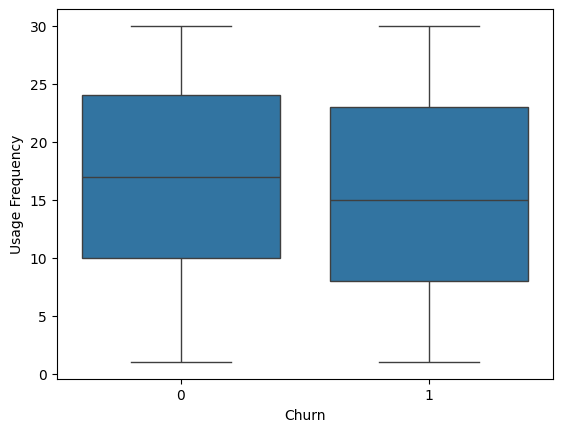

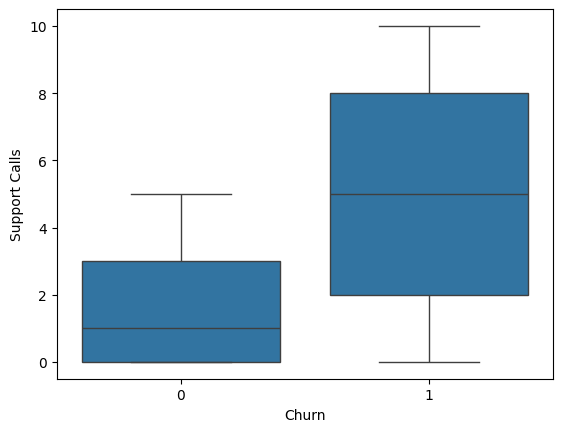

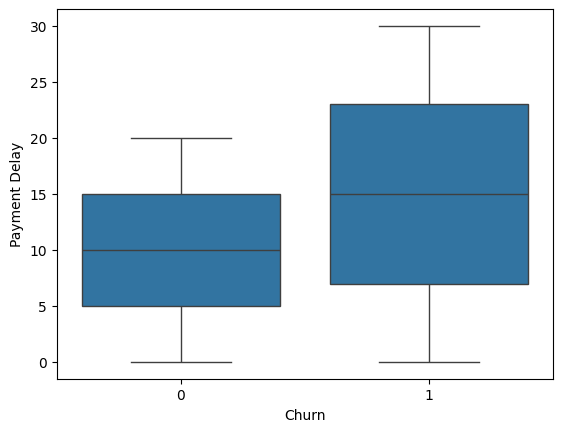

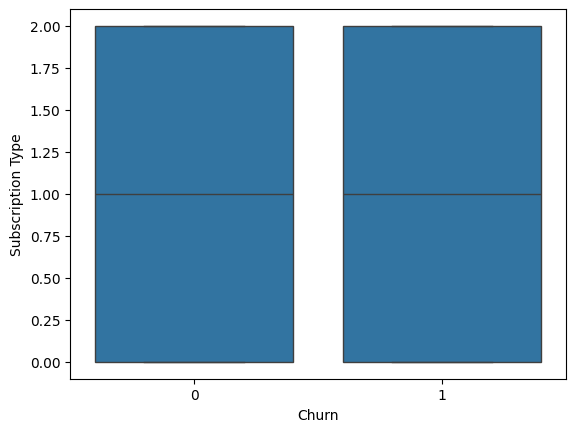

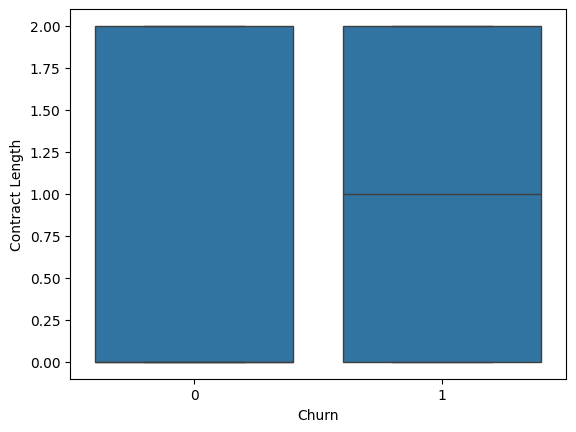

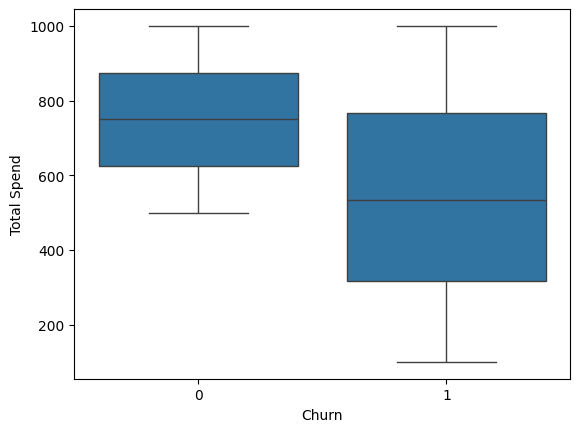

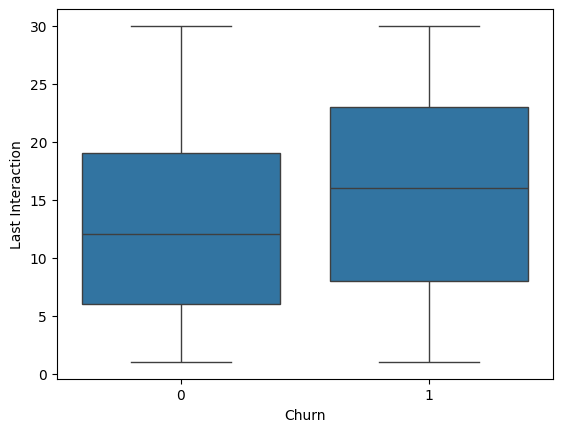

In [170]:
numeric_cols = [c for c in numeric_features if c != "Churn"]

for col in numeric_cols:
    sns.boxplot(x="Churn", y=col, data=df)
    plt.show()

d:\AI\tf-usage\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


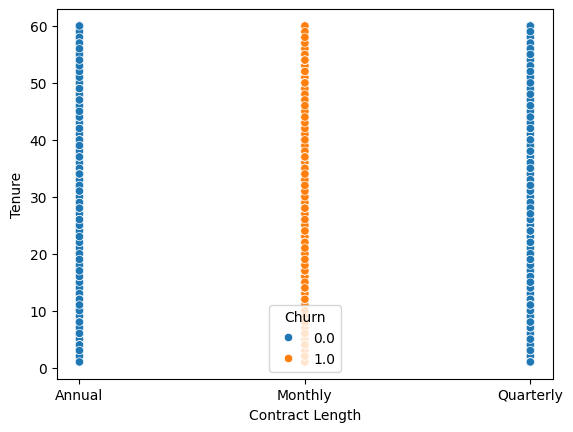

In [222]:
sns.scatterplot(x=df["Contract Length"], y=df["Tenure"], hue=df["Churn"])
plt.show()

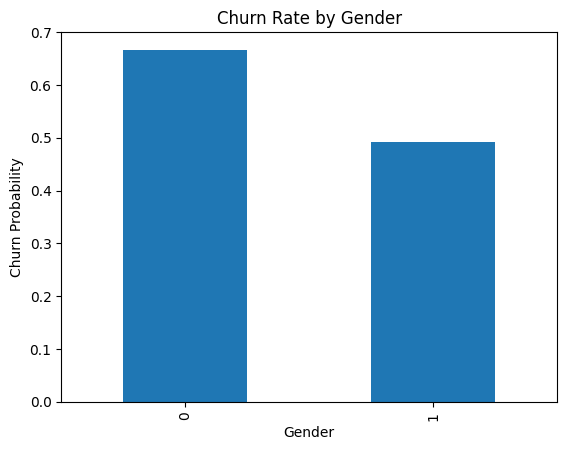

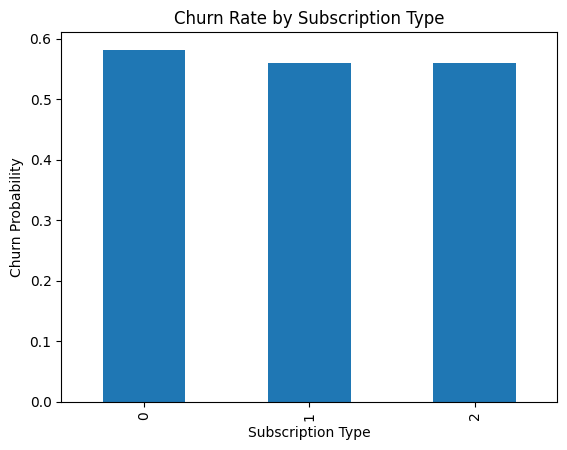

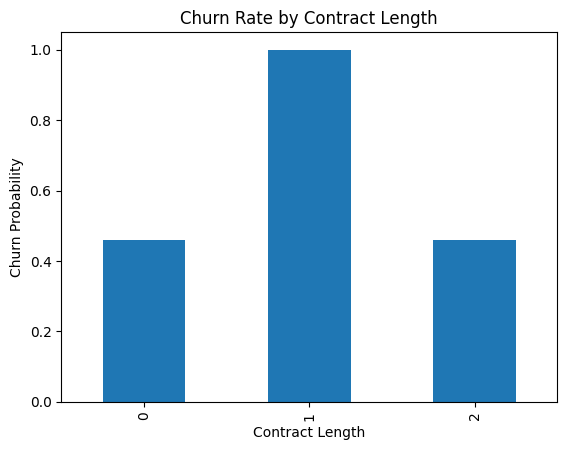

In [175]:
for col in categorical_features:
    churn_rate = df.groupby(col)["Churn"].mean()
    churn_rate.plot(kind="bar")
    plt.title(f"Churn Rate by {col}")
    plt.ylabel("Churn Probability")
    plt.show()

In [177]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object')

d:\AI\tf-usage\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


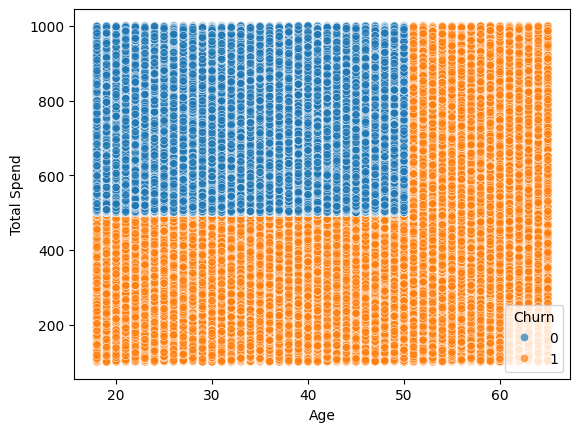

In [176]:
sns.scatterplot(data=df, x="Age", y="Total Spend", hue="Churn", alpha=0.7)
plt.show()

d:\AI\tf-usage\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


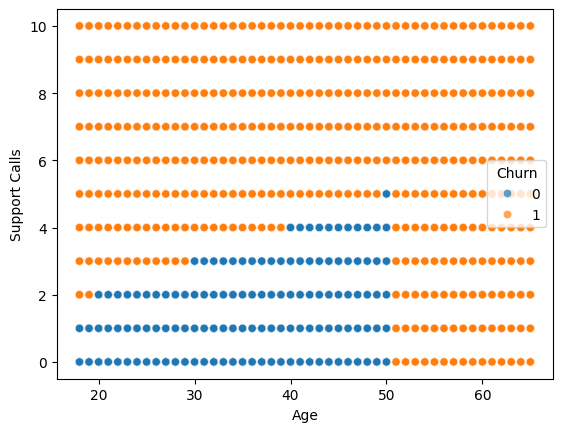

In [185]:
sns.scatterplot(data=df, y="Support Calls", x="Age", hue="Churn", alpha=0.7)
plt.show()

d:\AI\tf-usage\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


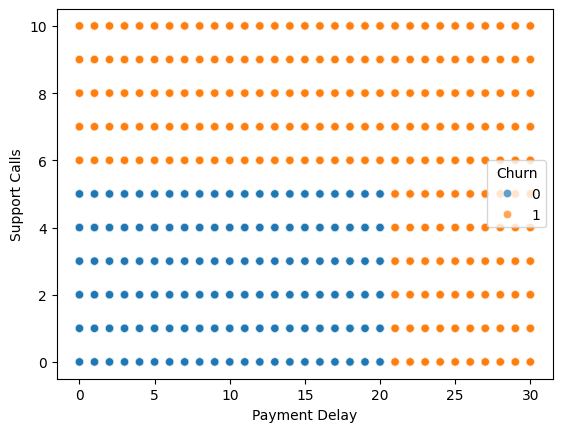

In [186]:
sns.scatterplot(data=df, y="Support Calls", x="Payment Delay", hue="Churn", alpha=0.7)
plt.show()

In [4]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler

In [12]:
nemeric_imputer_trf = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="mean"),
        )
    ]
)

nemeric_scaler_trf = Pipeline(steps=[("scaler", RobustScaler())])

categorical_trf = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
        ),
    ]
)

trf = ColumnTransformer(
    transformers=[
        ("cat", categorical_trf, categorical_features),
        ("num", nemeric_imputer_trf, numeric_features_imputing),
        ("scaler", nemeric_scaler_trf, numeric_features),
    ],
    remainder="passthrough",
    verbose_feature_names_out=False,
).set_output(transform="pandas")

In [8]:
xgbrf_params = {
    "model__n_estimators": 1000,  # Number of trees in the ensemble (more trees = better performance but slower)
    "model__learning_rate": 0.9,  # Step size shrinkage; has minimal effect in RF mode, but still present
    "subsample": 0.8,  # Fraction of rows (data samples) used for each tree (adds randomness like bagging)
    "colsample_bynode": 0.7,  # Fraction of features (columns) used per split (node) — like max_features in RF
    "max_depth": 6,  # Maximum depth of each decision tree
    "max_leaves": 0,  # Maximum number of terminal nodes; 0 means no limit (used in hist-based methods)
    "min_child_weight": 1.0,  # Minimum sum of instance weight (hessian) needed in a child (controls overfitting)
    "gamma": 0,  # Minimum loss reduction required to make a split (higher = more conservative)
    "reg_alpha": 0,  # L1 regularization on weights (sparsity)
    "reg_lambda": 2,  # L2 regularization on weights (used to avoid overfitting)
    "objective": "binary:logistic",  # Objective function — for binary classification
    "eval_metric": "logloss",  # Evaluation metric used during training
    "tree_method": "auto",  # Tree construction algorithm: 'auto', 'exact', 'approx', 'hist', 'gpu_hist'
    "max_bin": 256,  # Max number of histogram bins (used only with 'hist' or 'gpu_hist')
    "grow_policy": "depthwise",  # 'depthwise' (default) grows tree layer-by-layer; 'lossguide' grows leaf-wise
    "n_jobs": -1,  # Number of parallel threads to use (-1 = all cores)
    "random_state": 42,  # Random seed for reproducibility
    "verbosity": 1,  # Output verbosity: 0 (silent), 1 (warning), 2 (info), 3 (debug)
    "base_score": 0.8,  # Initial prediction score for all instances
    "importance_type": "weight",  # Feature importance calculation: 'weight', 'gain', 'cover', etc.
    "validate_parameters": True,  # Whether to validate parameters when passed
    "base_score": 0.80,
}

In [13]:
process = Pipeline(
    steps=[
        ("trf", trf),
    ]
)
fd = process.fit_transform(df)

In [6]:
class FeaturePipe:
    def __init__(self):
        self.cat_features = ["Gender", "Subscription Type", "Contract Length"]
        self.num_features = ["Age", "Tenure", "Usage Frequency", "Total Spend"]

        self.cat_pipe = Pipeline(
            [
                (
                    "ohe",
                    OneHotEncoder(
                        sparse_output=False, handle_unknown="ignore"
                    ).set_output(transform="pandas"),
                )
            ]
        )

        self.num_pipe = Pipeline([("scaler", RobustScaler())])

        self.ct = ColumnTransformer(
            transformers=[
                ("cat", self.cat_pipe, self.cat_features),
                ("num", self.num_pipe, self.num_features),
            ],
            remainder="passthrough",
            verbose_feature_names_out=False,
        ).set_output(transform="pandas")

In [22]:
# df.drop(
#     columns=[
#         "Churn",
#         "CustomerID",
#         "Support Calls",
#         "Payment Delay",
#         "Last Interaction",
#     ]
# )
df.dropna(inplace=True)

In [16]:
df_0 = df[df["Churn"] == 0]
df_1 = df[df["Churn"] == 1]
df_0_sampled = df_0.sample(n=20000, random_state=42)
df_1_sampled = df_1.sample(n=20000, random_state=42)
df_100k = (
    pd.concat([df_0_sampled, df_1_sampled])
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

In [ ]:
smot = SMOTE(random_state=42)
tomekLinks = TomekLinks()
d = feature_pip.fit_transform(
    df_100k.drop(
        columns=[
            "Churn",
            "CustomerID",
            "Support Calls",
            "Payment Delay",
            "Last Interaction",
        ]
    )
)
xtrain, ytrain = tomekLinks.fit_resample(
    d,
    df["Churn"].astype(int),
)

In [18]:
param_grid = {
    "n_estimators": [200, 100],
    "max_depth": [6, 8, 10, 12],
    "min_samples_leaf": [5, 10, 20],
    "min_samples_split": [10, 20, 40],
    "max_features": ["sqrt", "log2", 0.3],
    "bootstrap": [True],
}


search = RandomizedSearchCV(
    VotingClassifier(
        estimators=[
            ("RandomForestClassifier", RandomForestClassifier),
            ("LogisticRegression", LogisticRegression),
        ]
    ),
    param_grid,
    n_iter=20,
    cv=5,
    scoring="f1",
    n_jobs=-1,
)

In [41]:
clf1 = RandomForestClassifier()
clf2 = LogisticRegression()
clf3 = XGBClassifier()
v = VotingClassifier(
    estimators=[
        ("RandomForestClassifier", clf1),
        ("LogisticRegression", clf2),
        ("XGBClassifier", clf3),
    ],
    voting="soft",
)
v.fit(
    feature_pip.transform(
        df_100k.drop(
            columns=[
                "Churn",
                "CustomerID",
                "Support Calls",
                "Payment Delay",
                "Last Interaction",
            ]
        )
    ),
    df_100k["Churn"],
)

,estimators,"[('RandomForestClassifier', ...), ('LogisticRegression', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1


In [45]:
pred = v.predict(
    feature_pip.transform(
        test.iloc[:, :].drop(
            columns=[
                "Churn",
                "CustomerID",
                "Support Calls",
                "Payment Delay",
                "Last Interaction",
            ]
        )
    ),
)

In [46]:
print(classification_report(pred, test["Churn"].astype(int)))

              precision    recall  f1-score   support

         0.0       0.25      0.63      0.36     13585
         1.0       0.84      0.50      0.63     50789

    accuracy                           0.53     64374
   macro avg       0.54      0.57      0.49     64374
weighted avg       0.71      0.53      0.57     64374



In [ ]:
p = FeaturePipe()
pipel = Pipeline(
    steps=[
        ("trf", feature_pip),
        ("model", search),
    ]
)
pipel.fit(
    df_100k.drop(
        columns=[
            "Churn",
            "CustomerID",
            "Support Calls",
            "Payment Delay",
            "Last Interaction",
        ]
    ),
    df_100k["Churn"].astype(int),
)

In [9]:
# m = pipel.named_steps["model"]

In [ ]:
import joblib

joblib.dump(pipel, "churn_clf.joblib")

l = joblib.load("churn_clf.joblib")
feature_pip = l.named_steps["trf"]
model = l.named_steps["model"]

In [146]:
p = pipel.predict_proba(input_df)

In [154]:
import shap

background = pd.read_csv("./shap_background.csv")

shap_explainer = shap.Explainer(model.predict_proba, masker=background)

In [155]:
background

,Gender_Female,Gender_Male,Subscription Type_Basic,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Annual,Contract Length_Monthly,Contract Length_Quarterly,Age,Tenure,Usage Frequency,Total Spend
0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,-0.578947,-0.400000,0.785714,-0.184271
1,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,-0.947368,-0.233333,-0.428571,-1.060226
2,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.000000,0.333333,-1.071429,0.633219
3,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.105263,-0.666667,0.785714,-0.926188
4,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,-0.894737,-0.433333,-0.357143,-1.089274
...,...,...,...,...,...,...,...,...,...,...,...,...
295,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,-1.000000,-0.833333,0.500000,-0.453824
296,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,-1.000000,-0.766667,0.857143,0.735193
297,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.157895,0.733333,1.000000,-0.723162
298,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.526316,-0.333333,0.785714,0.931696


In [157]:
shap_val = shap_explainer(feature_pip.transform(input_df))

In [161]:
background.columns

Index(['Gender_Female', 'Gender_Male', 'Subscription Type_Basic',
       'Subscription Type_Premium', 'Subscription Type_Standard',
       'Contract Length_Annual', 'Contract Length_Monthly',
       'Contract Length_Quarterly', 'Age', 'Tenure', 'Usage Frequency',
       'Total Spend'],
      dtype='object')

In [159]:
shap_val

.values =
array([[[ 0.01756742, -0.01756742],
        [ 0.01934616, -0.01934616],
        [-0.00055042,  0.00055042],
        [-0.00071921,  0.00071921],
        [ 0.00067384, -0.00067384],
        [ 0.06122423, -0.06122423],
        [ 0.04562961, -0.04562961],
        [-0.03513023,  0.03513023],
        [ 0.12392937, -0.12392937],
        [ 0.00425715, -0.00425715],
        [ 0.00064885, -0.00064885],
        [ 0.08156114, -0.08156114]]])

.base_values =
array([[0.5385521, 0.4614479]])

.data =
array([[ 0.        ,  1.        ,  0.        ,  0.        ,  1.        ,
         1.        ,  0.        ,  0.        ,  0.21052632,  0.06666667,
         4.28571429, 10.23133553]])

In [ ]:
def generate_reasons(shap_val):
    shap_df = pd.DataFrame(
        {
            "feature": [
                "Gender_Female",
                "Gender_Male",
                "Subscription Type_Basic",
                "Subscription Type_Premium",
                "Subscription Type_Standard",
                "Contract Length_Annual",
                "Contract Length_Monthly",
                "Contract Length_Quarterly",
                "Age",
                "Tenure",
                "Usage Frequency",
                "Total Spend",
            ],
            "shap_value": shap_val.values[0, :, 1],  # class=1 (churn)
        }
    )

    # Sort by absolute importance
    shap_df = shap_df.reindex(
        shap_df.shap_value.abs().sort_values(ascending=False).index
    )

    # Filter weak effects
    shap_df = shap_df[shap_df.shap_value.abs() > 0.01].sort_values(
        by="shap_value", ascending=False
    )

    reasons = []
    for _, row in shap_df.iterrows():
        if row.shap_value > 0:
            reason = (
                f"{row.feature} of customer is increasing churn probability "
                f"({row.shap_value:.2f})"
            )
        else:
            reason = (
                f"{row.feature} of customer is decreasing churn probability "
                f"({row.shap_value:.2f})"
            )

        reasons.append(reason)

    return reasons


generate_reasons(shap_val)

['Contract Length_Quarterly of customer is increasing churn probability (0.04)',
 'Gender_Female of customer is decreasing churn probability (-0.02)',
 'Gender_Male of customer is decreasing churn probability (-0.02)',
 'Contract Length_Monthly of customer is decreasing churn probability (-0.05)',
 'Contract Length_Annual of customer is decreasing churn probability (-0.06)',
 'Total Spend of customer is decreasing churn probability (-0.08)',
 'Age of customer is decreasing churn probability (-0.12)']

In [109]:
pipel.score(test.iloc[:, [1, 2, 3, 4, 7, 8, 9]], test["Churn"].astype(int))

0.626725613585705

In [106]:
j = l.predict(test.iloc[:, [1, 2, 3, 4, 7, 8, 9]])
print(classification_report(j, test["Churn"].astype(int)))

              precision    recall  f1-score   support

           0       0.25      0.63      0.36     13664
           1       0.83      0.50      0.63     50710

    accuracy                           0.53     64374
   macro avg       0.54      0.57      0.49     64374
weighted avg       0.71      0.53      0.57     64374



In [153]:
c = feature_pip.transform(df_100k.iloc[:300, :])
c.to_csv("./shap_background.csv", index=False)

In [3]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [143]:
from pydantic import Field, BaseModel, field_validator


class customerinput(BaseModel):
    gender: str = Field(..., description="customer gender")
    Subscription_type: str = Field(..., description="type of subscription")
    contract_length: str = Field(
        ..., description="contract length. e.g: monthly ,qurtaly,annual"
    )
    tenure: float = Field(..., ge=0, description="months with company")
    Age: int = Field(..., ge=18, le=100, description="customer age")
    Usage_Frequency: float = Field(
        ..., ge=0, description="usage frequency. e.g: like days in month"
    )
    Total_spend: float = Field(
        ..., ge=0, description="total amount user spends so fare or recent month"
    )

    @field_validator("gender")
    def validate_gender(cls, v):
        allowed = ["Male", "Female"]
        if v not in allowed:
            raise ValueError(f"gender must be one of {allowed}")
        return v

    @field_validator("Subscription_type")
    def subcrip_val(cls, v):
        allowed = ["Standard", "Premium", "Basic"]
        if v not in allowed:
            raise ValueError(f"subscription type must be one of {allowed}")
        return v

    @field_validator("contract_length")
    def val_contract(cls, v):
        allowed = ["Annual", "Monthly", "Quarterly"]
        if v not in allowed:
            raise ValueError(f"contract type must be one of {allowed}")
        return v


Gender = "Male"
Subscription_Type = "Standard"
Contract_Length = "Annual"
Tenure = 34
Usage_Frequency = 76
Age = 43
Total_Spend = 4000

customer_data = customerinput(
    gender=Gender,
    Subscription_type=Subscription_Type,
    contract_length=Contract_Length,
    tenure=Tenure,
    Age=Age,
    Usage_Frequency=Usage_Frequency,
    Total_spend=Total_Spend,
)

# Create DataFrame for prediction
input_df = pd.DataFrame(
    [
        {
            "Gender": customer_data.gender,
            "Subscription Type": customer_data.Subscription_type,
            "Contract Length": customer_data.contract_length,
            "Tenure": customer_data.tenure,
            "Age": customer_data.Age,
            "Usage Frequency": customer_data.Usage_Frequency,
            "Total Spend": customer_data.Total_spend,
        }
    ]
)
input_df

,Gender,Subscription Type,Contract Length,Tenure,Age,Usage Frequency,Total Spend
0,Male,Standard,Annual,34.0,43,76.0,4000.0


In [11]:
model.predict_proba(feature_pip.transform(input_df))

array([[0.64, 0.36]])

In [ ]:
v = feature_pip.transform(df.iloc[:100, [1, 2, 3, 4, 7, 8, 9]])
v

,Gender_Female,Gender_Male,Subscription Type_Basic,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Annual,Contract Length_Monthly,Contract Length_Quarterly,Age,Tenure,Usage Frequency,Total Spend
0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,-0.473684,0.233333,-0.142857,0.774286


In [445]:
model.score(
    X_new.drop(
        columns=[
            "Churn",
            "CustomerID",
            "Last Interaction",
            "Payment Delay",
            "Support Calls",
        ]
    ),
    X_new["Churn"].astype(int),
)

0.7735533333333333

In [375]:
xtest = pipe.transform(df.iloc[200000:260000, :])

In [376]:
rf.score(xtest.drop(columns=["Churn"]), xtest["Churn"].astype(int))

0.9930666666666667

In [14]:
test_trf = process.fit_transform(test)

In [278]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [105]:
le = LabelEncoder()
for col in categorical_features:
    df[col] = le.fit_transform(df[col])

In [287]:
df.dropna(inplace=True)

In [289]:
from sklearn.model_selection import StratifiedKFold

stratified_kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for t, g in stratified_kf.split(df.drop(columns=["Churn"]), df["Churn"]):
    d = t
    f = g

In [299]:
f

array([    14,     18,     23, ..., 440819, 440821, 440826])

In [6]:
df["Churn"] = df["Churn"].fillna(0).astype(int)
df["Churn"] = df["Churn"].astype(dtype=int)
# fd.dropna(inplace=True)

In [22]:
test_trf.skew()

Gender               0.134897
Subscription Type   -0.001456
Contract Length      0.016305
Churn                0.105408
CustomerID           0.000000
Age                 -0.040894
Tenure              -0.126056
Usage Frequency      0.037543
Support Calls       -0.192854
Payment Delay       -0.350714
Total Spend          0.047746
Last Interaction     0.005112
dtype: float64

In [7]:
x = df.drop(
    columns=[
        "Churn",
        "CustomerID",
        "Support Calls",
        "Payment Delay",
        "Last Interaction",
    ],
    axis=1,
)
y = df["Churn"].astype(int)


X_train, X_test, y_train, y_test = (
    x,
    test.drop(
        columns=[
            "Churn",
            "CustomerID",
            "Support Calls",
            "Payment Delay",
            "Last Interaction",
        ]
    ),
    y,
    test["Churn"].astype(int),
)

In [ ]:
xgmodel = XGBClassifier()
logistic = LogisticRegression()
adaclf = AdaBoostClassifier()
randomclf = RandomForestClassifier()
gredclf = GradientBoostingClassifier()
detree = DecisionTreeClassifier()
bagingclf = BaggingClassifier()

model_list = [xgmodel, logistic, adaclf, randomclf, gredclf, detree, bagingclf]
for i in model_list:
    print(i.__class__.__module__)
    print(i.fit(X_train, y_train))
    print(
        "trainin score",
        i.score(X_train, y_train),
        "testing score",
        i.score(X_test, y_test),
    )

In [144]:
print(y.value_counts())

Churn
1    249999
0    249999
Name: count, dtype: int64


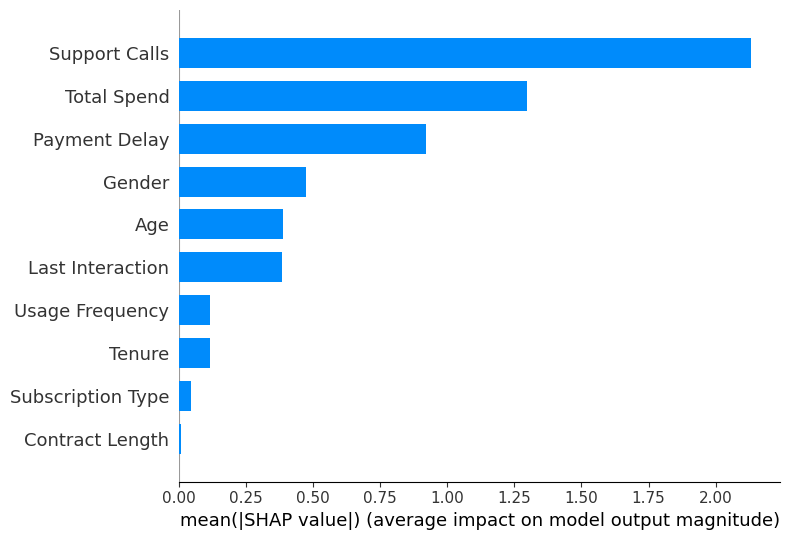

In [256]:
shap.summary_plot(shap_val, X_train, plot_type="bar", show=False)

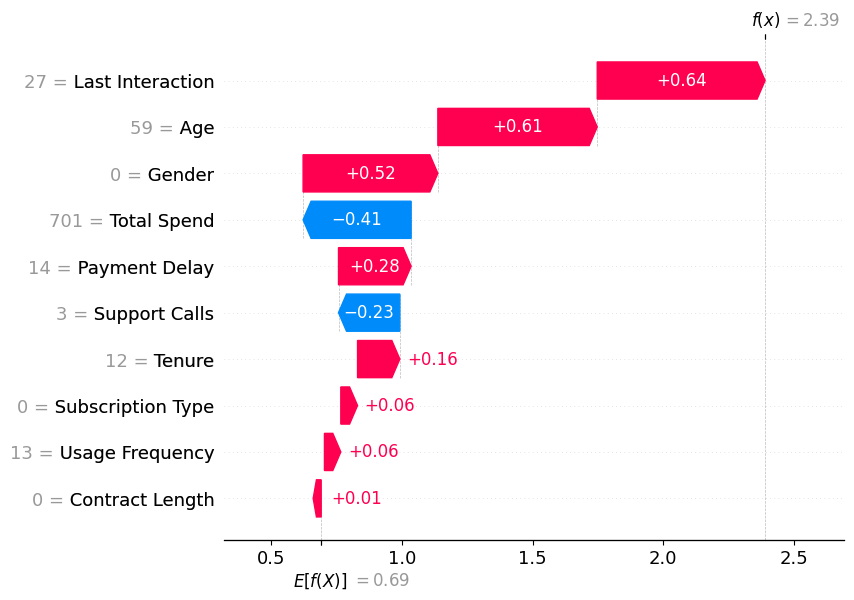

In [255]:
shap.waterfall_plot(
    shap.Explanation(
        values=shap_val[567],
        base_values=explainer.expected_value,
        data=X_test.iloc[567],
        feature_names=X_test.columns.tolist(),
    )
)

<BarContainer object of 2 artists>

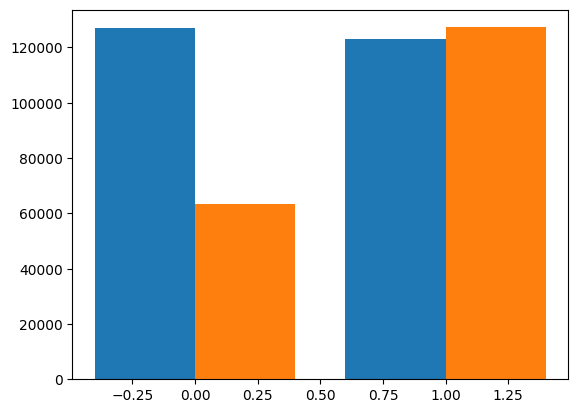

In [277]:
gender_churn = df.groupby(["Gender", "Churn"]).size().unstack()

X = list(gender_churn.index)
churn_0 = list(gender_churn.iloc[:, 0])
churn_1 = list(gender_churn.iloc[:, 1])

X_axis = np.arange(len(X))

plt.bar(X_axis - 0.2, churn_1, 0.4, label="Churn")
plt.bar(X_axis + 0.2, churn_0, 0.4, label="Not Churn")

In [276]:
X_axis

array([0, 1])

In [267]:
gender_churn

Churn,0.0,1.0
Gender,,
Female,63522,127058
Male,127311,122941


In [ ]:
from sklearn.metrics import RocCurveDisplay

for i in model_list:
    RocCurveDisplay.from_estimator(i, X_test, y_test)
    plt.show()

In [138]:
from scipy.stats import randint


randomclf = RandomForestClassifier(random_state=42)

param_grid = {
    "n_estimators": randint(50, 100),
    "max_depth": [5, 10, 8, 12],
    "min_samples_split": randint(2, 15),
    "min_samples_leaf": randint(1, 10),
    "max_features": ["sqrt", "log2"],
}

randomizedSearchCv = RandomizedSearchCV(
    estimator=randomclf,
    param_distributions=param_grid,
    n_iter=20,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=3,
)
randomizedSearchCv.fit(X_train, y_train)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': [5, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': <scipy.stats....0017C9276BE20>, 'min_samples_split': <scipy.stats....0017C893D3C10>, ...}"
,n_iter,30
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,3
,verbose,3
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [154]:
randomizedSearchCv.best_params_

{'max_depth': 12,
 'max_features': 'sqrt',
 'min_samples_leaf': 2,
 'min_samples_split': 14,
 'n_estimators': 91}

In [145]:
randomizedSearchCv.score(X_train, y_train), randomizedSearchCv.score(X_test, y_test)

(0.9353677153187567, 0.5537368819944947)

In [1]:
import joblib

loded_baging = joblib.load(".\churn_pipeline.joblib")

In [50]:
x_train

,Gender,Subscription Type,Contract Length,Age,Tenure,Usage Frequency,Total Spend
0,0.0,2.0,0.0,-0.473684,0.233333,-0.142857,0.774286
1,0.0,0.0,1.0,1.368421,0.566667,-1.071429,-0.297143
2,0.0,0.0,2.0,0.842105,-0.600000,-0.857143,-1.360000
3,1.0,2.0,1.0,1.000000,0.200000,0.357143,-0.757143
4,1.0,0.0,1.0,-0.842105,0.000000,0.285714,-0.125714
...,...,...,...,...,...,...,...
440828,1.0,1.0,0.0,0.157895,0.733333,-0.071429,0.158229
440829,0.0,1.0,0.0,-0.736842,-0.800000,-0.214286,0.241086
440830,1.0,2.0,2.0,-0.684211,0.100000,0.785714,0.903743
440831,1.0,2.0,2.0,-0.578947,0.766667,-0.142857,-0.167000


In [2]:
model = loded_baging.named_steps["model"]
transfomation = loded_baging.named_steps["features"]

In [4]:
import shap
import pandas as pd

background = pd.read_csv("shap_background.csv")
explainer = shap.Explainer(model.predict_proba, masker=background)

In [175]:
g = background.iloc[:5, :]
g

,Gender,Subscription Type,Contract Length,Age,Tenure,Usage Frequency,Total Spend
0,1.0,2.0,1.0,-0.631579,-0.600000,0.857143,0.574286
1,1.0,2.0,1.0,0.052632,-0.433333,-1.000000,-0.114829
2,0.0,2.0,0.0,-0.631579,0.833333,-0.928571,0.725714
3,1.0,0.0,0.0,0.052632,-0.366667,-0.142857,-0.194771
4,1.0,2.0,1.0,0.000000,0.866667,-0.857143,0.094286


In [17]:
from featurepipline import FeaturePipe

p = FeaturePipe()
p.fit(X_train)
l = p.transform(g)
l

,Gender,Subscription Type,Contract Length,Age,Tenure,Usage Frequency,Total Spend
0,0.0,2.0,0.0,-0.473684,0.233333,-0.142857,0.774286


In [180]:
model.predict(g)

array([1, 1, 0, 0, 1])

In [170]:
shap_val = explainer(g)

In [205]:
def generate_reasons(shap_val):
    shap_df = pd.DataFrame(
        {
            "feature": [
                "Gender",
                "Subscription Type",
                "Contract Length",
                "Age",
                "Tenure",
                "Usage Frequency",
                "Total Spend",
            ],
            "shap_value": shap_val.values[0, :, 1],  # class=1 (churn)
        }
    )

    # Sort by absolute importance
    shap_df = shap_df.reindex(
        shap_df.shap_value.abs().sort_values(ascending=False).index
    )

    # Filter weak effects
    shap_df = shap_df[shap_df.shap_value.abs() > 0.1]

    reasons = []
    for _, row in shap_df.iterrows():
        if row.shap_value > 0:
            reason = (
                f"{row.feature} of customer is increasing churn probability "
                f"({row.shap_value:.2f})"
            )
        else:
            reason = (
                f"{row.feature} of customer is decreasing churn probability "
                f"({row.shap_value:.2f})"
            )

        reasons.append(reason)

    return reasons

In [208]:
reason = generate_reasons(shap_val)

reasons_html = "<ul>" + "".join(f"<li>➡️ {s}</li>" for s in reason) + "</ul>"

In [202]:
reasons_html

'<ul><li>➡️ Contract Length of customer is increasing churn probability (0.38)</li><li>➡️ Total Spend of customer is decreasing churn probability (-0.06)</li><li>➡️ Usage Frequency of customer is decreasing churn probability (-0.02)</li><li>➡️ Gender of customer is decreasing churn probability (-0.02)</li><li>➡️ Age of customer is decreasing churn probability (-0.02)</li><li>➡️ Tenure of customer is increasing churn probability (0.02)</li></ul>'

In [124]:
shap_vals = shap_val.values[0][:, 1]

In [203]:
import numpy as np

In [209]:
reason

['Contract Length of customer is increasing churn probability (0.38)']

In [107]:
reasons_html = ""
for reason in reason:
    icon = "⬆️" if reason["direction"] == "increasing" else "⬇️"
    direction_class = reason["direction"]
    reasons_html += f"""
    <div class="reason-item">
        <span class="reason-icon {direction_class}">{icon}</span>
        <strong>{reason['feature']}</strong> is <span class="{direction_class}">{reason['direction']}</span> 
            churn risk by {abs(reason['value']):.3f} - Take action!
    </div>
    """

In [108]:
reasons_html

'\n    <div class="reason-item">\n        <span class="reason-icon decreasing">⬇️</span>\n        <strong>Total Spend</strong> is <span class="decreasing">decreasing</span> \n            churn risk by 0.148 - Take action!\n    </div>\n    \n    <div class="reason-item">\n        <span class="reason-icon decreasing">⬇️</span>\n        <strong>Contract Length</strong> is <span class="decreasing">decreasing</span> \n            churn risk by 0.110 - Take action!\n    </div>\n    \n    <div class="reason-item">\n        <span class="reason-icon decreasing">⬇️</span>\n        <strong>Age</strong> is <span class="decreasing">decreasing</span> \n            churn risk by 0.100 - Take action!\n    </div>\n    \n    <div class="reason-item">\n        <span class="reason-icon increasing">⬆️</span>\n        <strong>Gender</strong> is <span class="increasing">increasing</span> \n            churn risk by 0.052 - Take action!\n    </div>\n    \n    <div class="reason-item">\n        <span class="re